# Homework 3

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

For the econometric analysis, we use the datasets from the folder 70701808

## Packages

In [14]:
library(fst)
library(highfrequency)
library(xts)

Warning message:
"package 'highfrequency' was built under R version 4.5.3"
Warning message:
"package 'xts' was built under R version 4.5.2"
Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




## Data import

In [6]:
dates<-read.csv("students_HW3/70701808_periods_HW_3.csv")
msft<-read.fst("HW_3_data/HW_3_MSFT_1min.fst")
bac<-read.fst("HW_3_data/HW_3_BAC_1min.fst")
xom<-read.fst("HW_3_data/HW_3_XOM_1min.fst")

Warning message:
"package 'fstcore' was built under R version 4.5.3"


In [7]:
head(dates)

,X,Ticker,Start,End
,<int>,<chr>,<int>,<int>
1,1,MSFT,2011,2016
2,2,BAC,2012,2016
3,3,XOM,2015,2016


In [11]:
print(dim(msft))
head(msft)

[1] 933337      2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:44:00,24.6994
2,2010-01-04 07:56:00,24.6673
3,2010-01-04 08:00:00,24.6593
4,2010-01-04 08:01:00,24.6272
5,2010-01-04 08:05:00,24.6192
6,2010-01-04 08:06:00,24.6192


In [13]:
print(dim(bac))
head(bac)

[1] 1134050       2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:00:00,14.0864
2,2010-01-04 07:04:00,14.0864
3,2010-01-04 07:06:00,14.0679
4,2010-01-04 07:08:00,14.0586
5,2010-01-04 07:13:00,14.0772
6,2010-01-04 07:21:00,14.1050


In [12]:
print(dim(xom))
head(xom)

[1] 882799      2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:01:00,52.6728
2,2010-01-04 07:02:00,52.6728
3,2010-01-04 07:03:00,52.6728
4,2010-01-04 07:04:00,52.6345
5,2010-01-04 07:05:00,52.6728
6,2010-01-04 07:09:00,52.6728


In [29]:
prepare_hf_data <- function(df, ticker, dates_df) {
  
  # Get start and end years dynamically
  start_yr <- dates_df$Start[dates_df$Ticker == ticker]
  end_yr   <- dates_df$End[dates_df$Ticker == ticker]
  
  # A. Convert to xts
  df_xts <- xts(df$V1, order.by = df$index)
  colnames(df_xts) <- "Price"
  
  # B. Filter by Years and Time (Chained together for simplicity)
  df_filtered <- df_xts[paste0(start_yr, "/", end_yr)]["T07:00/T18:00"]
  
  # C. Calculate Intraday Returns (Split by days, apply makeReturns, bind rows)
  returns <- do.call(rbind, lapply(split(df_filtered, "days"), makeReturns))
  
  # D. Combine Price and Returns side-by-side
  df_final <- cbind(df_filtered, Returns = returns)
  colnames(df_final) <- c("Price", "Returns")
  cat(sprintf("Done: %s (%d-%d)\n", ticker, start_yr, end_yr))
  return(df_final)
}

In [30]:
msft_clean <- prepare_hf_data(msft, "MSFT", dates)
bac_clean  <- prepare_hf_data(bac,  "BAC",  dates)
xom_clean  <- prepare_hf_data(xom,  "XOM",  dates)

Done: MSFT (2011-2016)
Done: BAC (2012-2016)
Done: XOM (2015-2016)


In [31]:
head(msft_clean)

Warning message:
"object timezone ('UTC') is different from system timezone ('')"


                      Price      Returns
2011-01-03 07:19:00 23.0110  0.000000000
2011-01-03 07:36:00 22.9864 -0.001069626
2011-01-03 07:48:00 22.9864  0.000000000
2011-01-03 07:49:00 22.9700 -0.000713720
2011-01-03 07:50:00 22.9700  0.000000000
2011-01-03 07:51:00 22.9700  0.000000000

In [37]:
compare_rv <- function(clean_data, ticker) {
  
  # 1. Calculate the daily Realized Variances using both methods
  rv_from_prices  <- rCov(clean_data[, "Price"], makeReturns = TRUE)
  rv_from_returns <- rCov(na.omit(clean_data[, "Returns"]), makeReturns = FALSE)
  
  # 2. Calculate the difference (Prices method minus Returns method)
  rv_diff <- rv_from_prices - rv_from_returns
  
  # 3. Calculate the summary statistics of those differences
  min_diff <- min(rv_diff, na.rm = TRUE)
  max_diff <- max(rv_diff, na.rm = TRUE)
  avg_diff <- mean(rv_diff, na.rm = TRUE)
  
  # 4. Print the formatted results
  cat(sprintf("\n--- %s RV Differences (Prices Method vs Returns Method) ---\n", ticker))
  cat(sprintf("Minimum Difference : %f\n", min_diff))
  cat(sprintf("Maximum Difference : %f\n", max_diff))
  cat(sprintf("Average Difference : %f\n", avg_diff))
}

In [38]:
compare_rv(msft_clean, "MSFT")
compare_rv(bac_clean,  "BAC")
compare_rv(xom_clean,  "XOM")


--- MSFT RV Differences (Prices Method vs Returns Method) ---
Minimum Difference : 0.000000
Maximum Difference : 0.000000
Average Difference : 0.000000

--- BAC RV Differences (Prices Method vs Returns Method) ---
Minimum Difference : 0.000000
Maximum Difference : 0.000000
Average Difference : 0.000000

--- XOM RV Differences (Prices Method vs Returns Method) ---
Minimum Difference : 0.000000
Maximum Difference : 0.000000
Average Difference : 0.000000


In [43]:
# Create a function to calculate, summarize, and plot the sub-periods
compare_subperiod_rv <- function(clean_data, ticker) {
  
  # 1. Define our time strings
  periods <- c("T07:00/T09:29", "T09:30/T10:59", "T11:00/T14:29", 
               "T14:30/T15:59", "T16:00/T18:00")
  
  period_names <- c("07:00-09:29", "09:30-10:59", "11:00-14:29", 
                    "14:30-15:59", "16:00-18:00")
  
  # Vectors/Lists to store our results
  avg_rv <- numeric(length(periods))
  daily_rv_list <- list()
  
  # 2. Loop through each sub-period
  for (i in 1:length(periods)) {
    
    # A. Subset the returns for ONLY this specific time window
    sub_returns <- na.omit(clean_data[periods[i], "Returns"])
    
    # B. Calculate the daily Realized Variance for this subset
    daily_rv <- rCov(sub_returns, makeReturns = FALSE)
    
    # C. Store the raw daily RVs for the boxplot
    daily_rv_list[[i]] <- as.numeric(daily_rv)
    
    # D. Calculate and store the Average RV for the bar chart
    avg_rv[i] <- mean(daily_rv, na.rm = TRUE)
  }
  
  # Set up a 1x2 grid to show two plots side-by-side
  par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1) 
  
  plot(avg_rv, type = "b", pch = 16, col = "red", lwd = 2, xaxt = "n",
     main = paste(ticker, "- Intraday Volatility Smile"),
     ylab = "Average Realized Variance", xlab = "Time Period")
     axis(1, at = 1:5, labels = period_names, las = 2)
  
  # Plot 2: Boxplot of Daily RVs 
  boxplot(daily_rv_list, names = period_names, col = "lightblue",
          main = paste(ticker, "- Daily RV Distribution"),
          ylab = "Daily Realized Variance",
          las = 2)
  
  # Reset plot layout back to normal (1x1)
  par(mfrow = c(1, 1))
  
  # Print the numeric averages to the console
  cat(sprintf("\n--- %s Average Realized Variance by Period ---\n", ticker))
  for(i in 1:length(periods)) {
    cat(sprintf("%s : %f\n", period_names[i], avg_rv[i]))
  }
}


--- MSFT Average Realized Variance by Period ---
07:00-09:29 : 0.000070
09:30-10:59 : 0.000073
11:00-14:29 : 0.000054
14:30-15:59 : 0.000029
16:00-18:00 : 0.000224


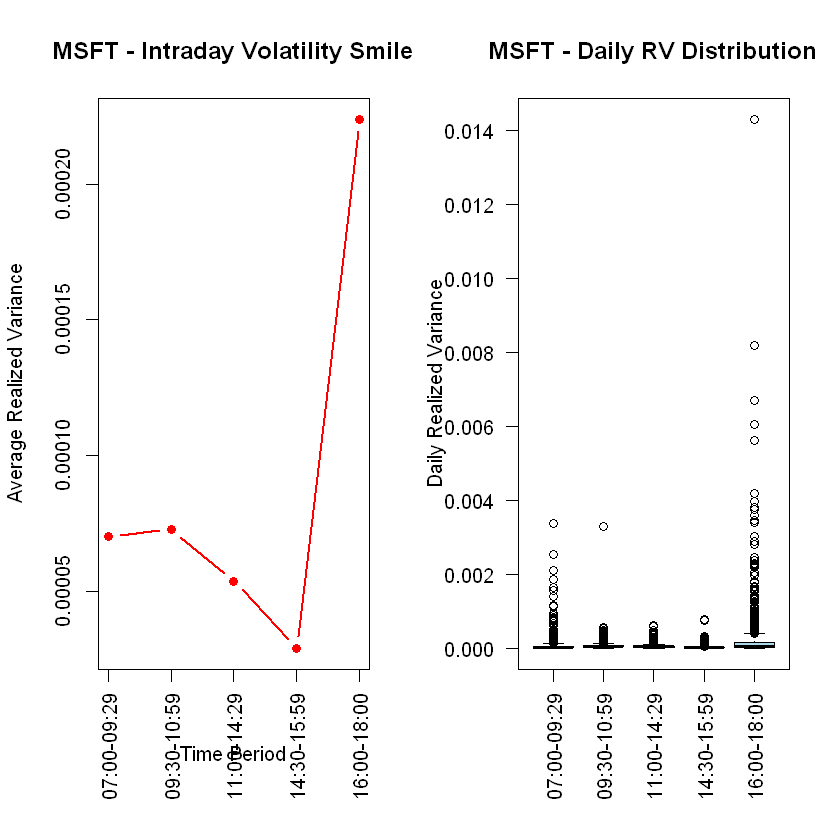


--- BAC Average Realized Variance by Period ---
07:00-09:29 : 0.000142
09:30-10:59 : 0.000130
11:00-14:29 : 0.000113
14:30-15:59 : 0.000051
16:00-18:00 : 0.000186


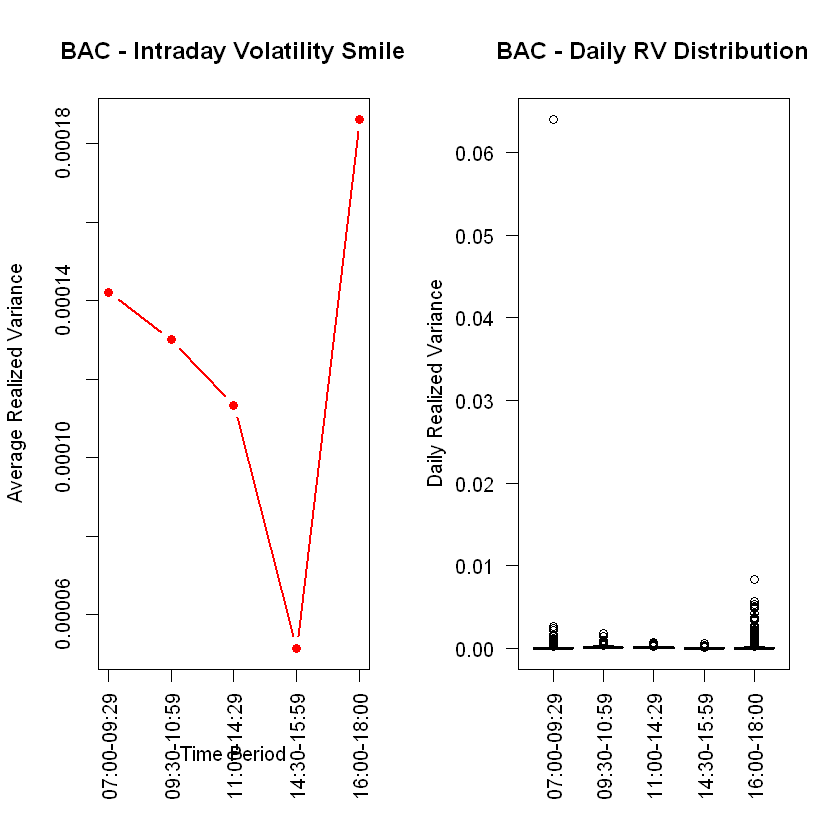


--- XOM Average Realized Variance by Period ---
07:00-09:29 : 0.000365
09:30-10:59 : 0.000070
11:00-14:29 : 0.000048
14:30-15:59 : 0.000023
16:00-18:00 : 0.000115


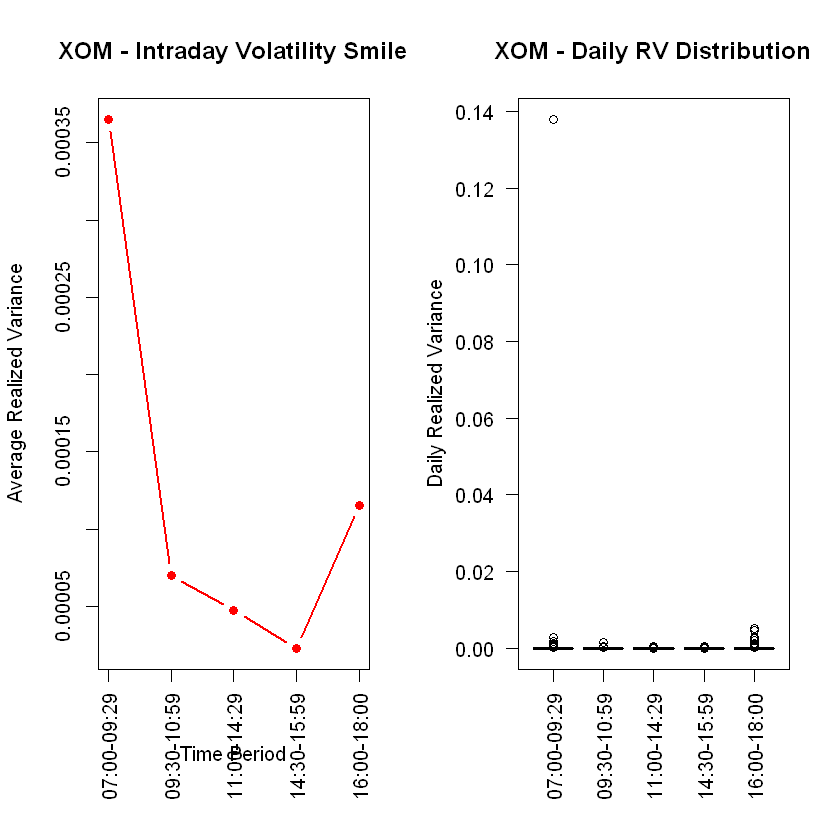

In [44]:
compare_subperiod_rv(msft_clean, "MSFT")
compare_subperiod_rv(bac_clean,  "BAC")
compare_subperiod_rv(xom_clean,  "XOM")

In [55]:
compare_rv_additivity <- function(clean_data, ticker) {
  
  # 1. Calculate Full Daily RV (07:00 - 18:00)
  rv_daily <- rCov(na.omit(clean_data$Returns), makeReturns = FALSE)
  colnames(rv_daily) <- "Full_RV"
  
  # 2. Calculate the Sub-period RVs
  periods <- c("T07:00/T09:29", "T09:30/T10:59", "T11:00/T14:29", 
               "T14:30/T15:59", "T16:00/T18:00")
  
  # Create a starting object for merging
  # This ensures all sub-periods align to the exact same daily dates
  combined_rvs <- rv_daily
  
  for (i in 1:length(periods)) {
    sub_ret <- na.omit(clean_data[periods[i], "Returns"])
    daily_sub_rv <- rCov(sub_ret, makeReturns = FALSE)
    colnames(daily_sub_rv) <- paste0("P", i)
    
    # Merge current sub-period into the main object
    # join='left' ensures we keep all days found in the Full_RV
    combined_rvs <- merge(combined_rvs, daily_sub_rv, join = "left")
  }
  
  # 3. Fill missing days with 0 (No trades = No variance)
  combined_rvs[is.na(combined_rvs)] <- 0
  
  # 4. Sum the sub-periods (Columns 2 through 6)
  rv_summed <- rowSums(combined_rvs[, 2:6])
  
  # 5. Compute the Difference (Full_RV is Column 1)
  rv_diff <- combined_rvs[, 1] - rv_summed
  
  # 6. Plotting
  par(mar = c(7, 4, 4, 2) + 0.1) 
  print(plot(rv_diff, main = paste(ticker, "Full RV vs. Summed RV"),
       col = "darkgreen", ylab = "Difference"))
  
  # 7. Summary Statistics
  cat(sprintf("\n--- %s Additivity Summary ---\n", ticker))
  cat(sprintf("Mean Difference: %e\n", mean(rv_diff, na.rm = TRUE)))
  cat(sprintf("Max Difference : %e\n", max(rv_diff, na.rm = TRUE)))
  cat(sprintf("Min Difference : %e\n", min(rv_diff, na.rm = TRUE)))
}


--- MSFT Additivity Summary ---
Mean Difference: 2.253065e-04
Max Difference : 4.992032e-03
Min Difference : 3.980335e-05


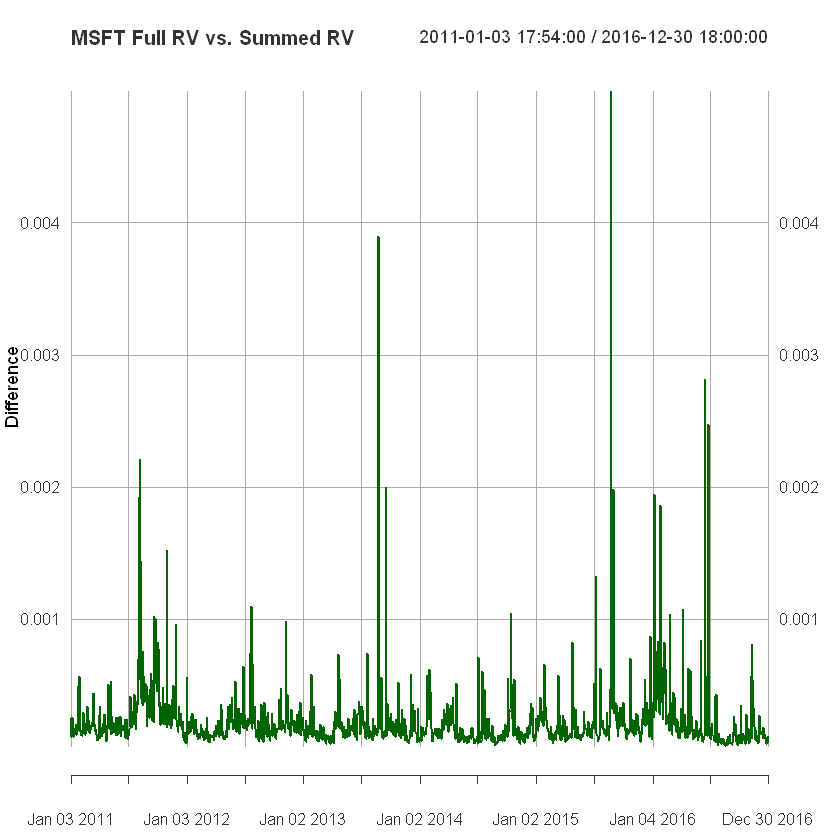


--- BAC Additivity Summary ---
Mean Difference: 4.368932e-04
Max Difference : 6.409329e-02
Min Difference : 5.932495e-05


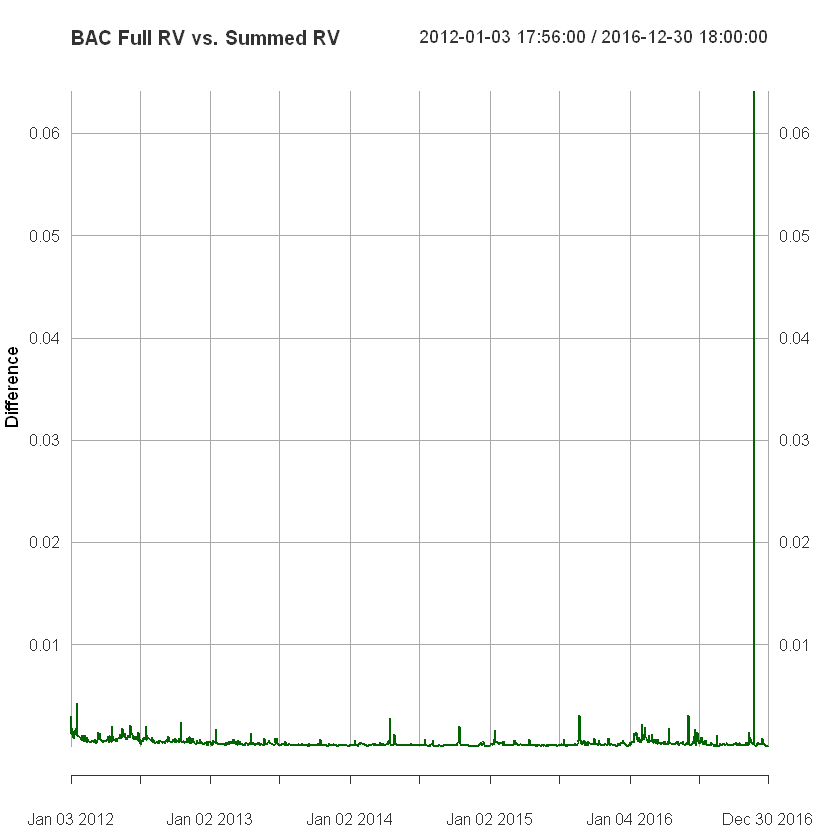


--- XOM Additivity Summary ---
Mean Difference: 5.048586e-04
Max Difference : 1.379139e-01
Min Difference : 2.371839e-05


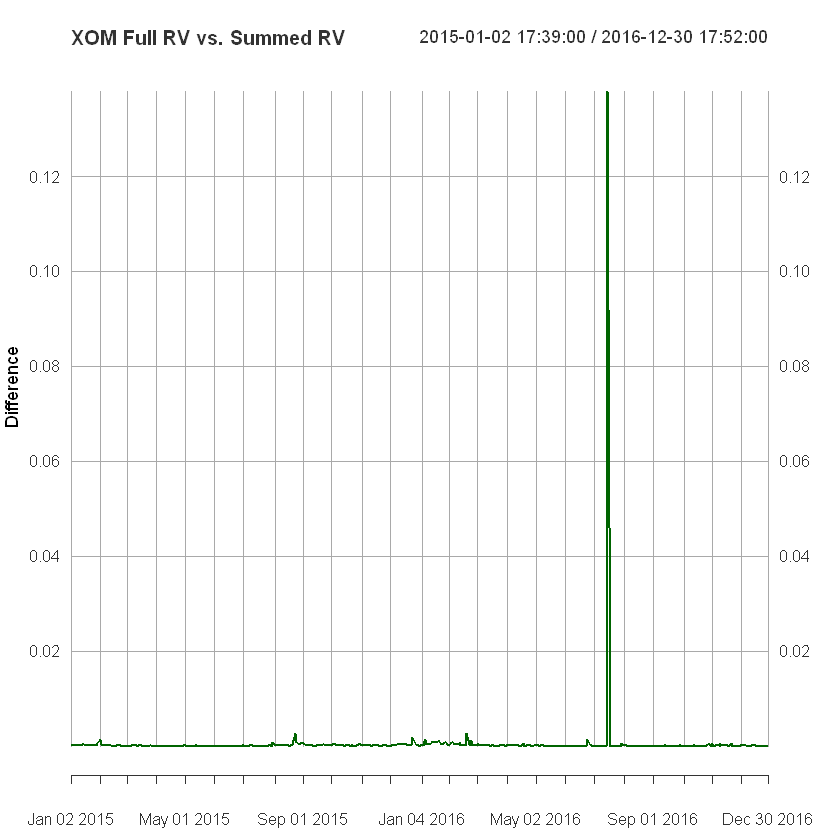

In [56]:
# Run for your datasets
compare_rv_additivity(msft_clean, "MSFT")
compare_rv_additivity(bac_clean,  "BAC")
compare_rv_additivity(xom_clean,  "XOM")

In [59]:
plot_rv_shares <- function(clean_data, ticker) {
  
  # 1. Define sub-period time windows and labels
  periods <- list(
    "07:00/09:29" = "07:00-09:29",
    "09:30/10:59" = "09:30-10:59",
    "11:00/14:29" = "11:00-14:29",
    "14:30/15:59" = "14:30-15:59",
    "16:00/18:00" = "16:00-18:00"
  )
  
  # 2. Get all unique trading dates
  all_dates <- unique(as.Date(index(clean_data)))
  
  # 3. For each period, compute RV per day manually
  # rCov() needs an xts object; we loop over dates to get one RV value per day
  rv_list <- lapply(names(periods), function(time_range) {
    
    daily_rvs <- sapply(all_dates, function(d) {
      # Subset to this date AND this intraday time window
      day_str   <- format(d, "%Y-%m-%d")
      window    <- paste0(day_str, " ", gsub("/", paste0("/", day_str, " "), time_range))
      sub_ret   <- na.omit(clean_data[window, "Returns"])
      
      if (nrow(sub_ret) < 2) return(NA_real_)
      
      # rCov returns a 1x1 matrix for univariate; extract the scalar
      as.numeric(rCov(sub_ret, makeReturns = FALSE))
    })
    
    # Return as xts so merge() preserves date alignment
    xts(daily_rvs, order.by = all_dates)
  })
  
  # 4. Merge into one multi-column xts (rows = days, cols = periods)
  combined_rvs <- do.call(merge, rv_list)
  combined_rvs[is.na(combined_rvs)] <- 0
  colnames(combined_rvs) <- unlist(unname(periods))
  
  # 5. Daily total RV = row sums across all sub-periods
  daily_total <- rowSums(combined_rvs)
  
  # 6. Percentage share per period per day; guard against zero-total days
  rv_shares <- sweep(combined_rvs, 1, daily_total, FUN = "/") * 100
  rv_shares[daily_total == 0, ] <- 0
  
  # 7. Average share across all trading days
  mean_shares <- colMeans(rv_shares, na.rm = TRUE)
  
  # 8. Plot
  bar_cols <- c("#2C7BB6", "#ABD9E9", "#FFFFBF", "#FDAE61", "#D7191C")
  bp <- barplot(
    mean_shares,
    main    = paste(ticker, "— Avg % Share of Intraday RV"),
    col     = bar_cols,
    ylim    = c(0, max(mean_shares, na.rm = TRUE) * 1.2),
    ylab    = "Percentage Share (%)",
    xlab    = "Intraday Period",
    las     = 2,
    border  = "white",
    cex.names = 0.85
  )
  
  # Labels on top of bars
  text(x = bp, y = mean_shares,
       labels = paste0(round(mean_shares, 1), "%"),
       pos = 3, cex = 0.85, font = 2)
  
  # 9. Console summary
  cat(sprintf("\n=== %s — RV Share Breakdown ===\n", ticker))
  for (i in seq_along(mean_shares)) {
    cat(sprintf("  %-15s : %6.2f%%\n", names(mean_shares)[i], mean_shares[i]))
  }
  cat(sprintf("  %-15s : %6.2f%%\n", "TOTAL", sum(mean_shares)))
  
  invisible(list(rv_shares = rv_shares, mean_shares = mean_shares))
}


=== MSFT — RV Share Breakdown ===
  07:00-09:29     :  17.99%
  09:30-10:59     :  24.33%
  11:00-14:29     :  17.80%
  14:30-15:59     :   8.82%
  16:00-18:00     :  31.06%
  TOTAL           : 100.00%


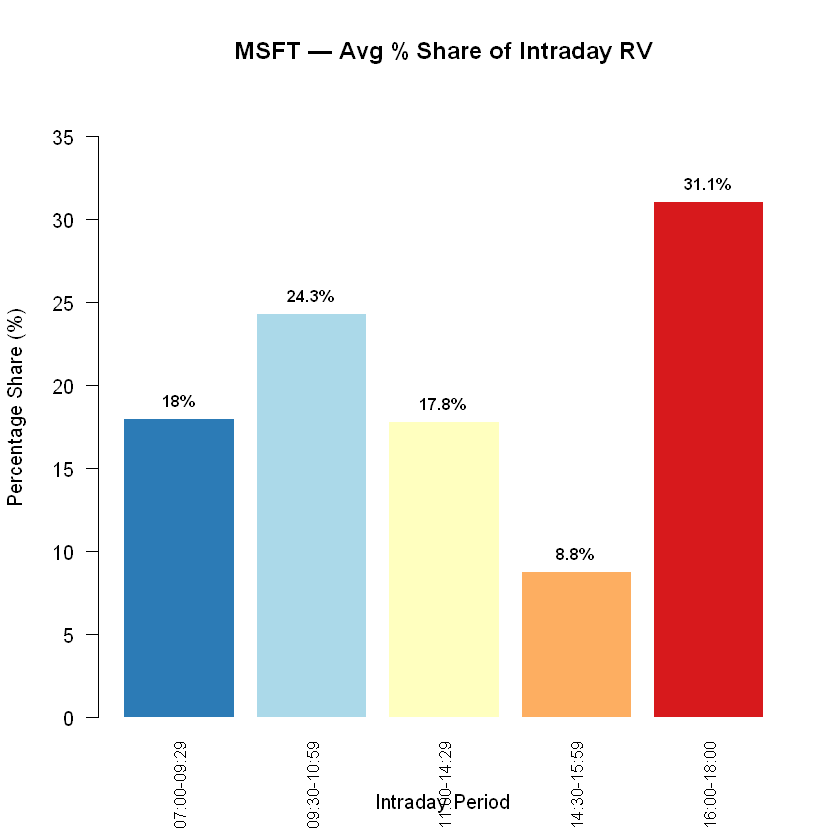


=== BAC — RV Share Breakdown ===
  07:00-09:29     :  17.24%
  09:30-10:59     :  29.13%
  11:00-14:29     :  25.05%
  14:30-15:59     :  10.90%
  16:00-18:00     :  17.68%
  TOTAL           : 100.00%


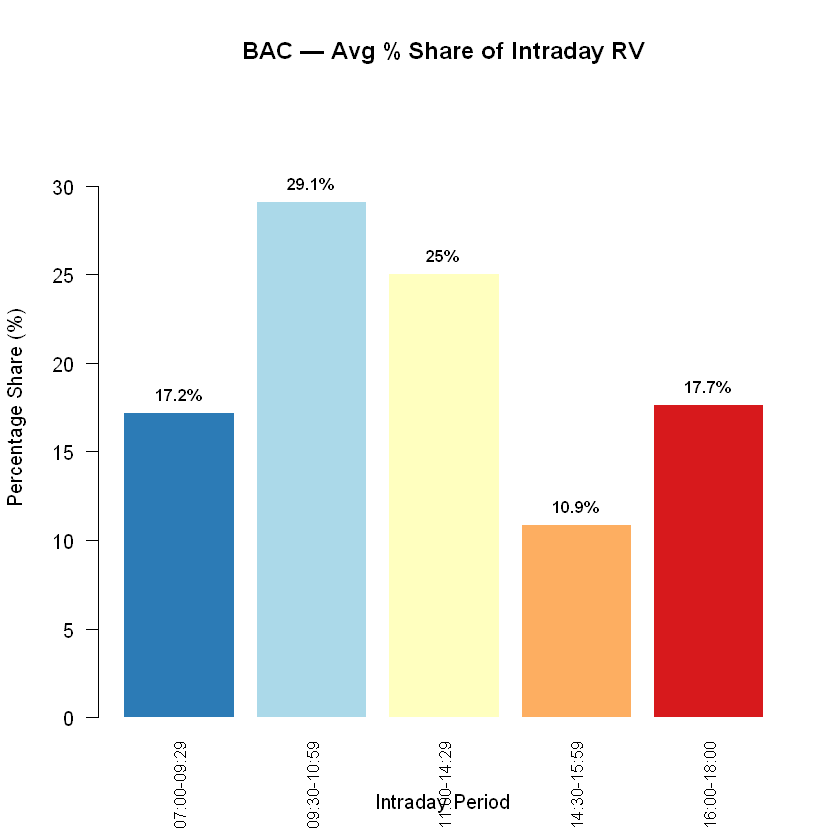


=== XOM — RV Share Breakdown ===
  07:00-09:29     :  25.35%
  09:30-10:59     :  27.03%
  11:00-14:29     :  18.70%
  14:30-15:59     :   8.12%
  16:00-18:00     :  20.79%
  TOTAL           : 100.00%


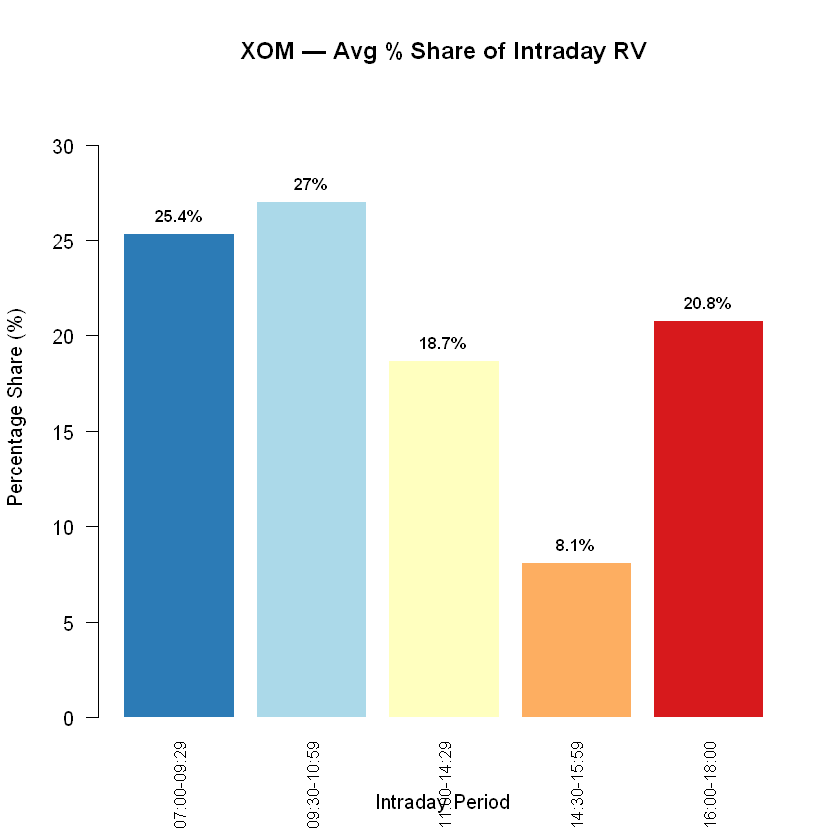

In [60]:
# Run for your datasets
plot_rv_shares(msft_clean, "MSFT")
plot_rv_shares(bac_clean,  "BAC")
plot_rv_shares(xom_clean,  "XOM")